#ETE Deep Learning

##Land Type Classifier for Autonomous Systems

### Import Library

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os

### Extracting the folder

In [ ]:
zip_path = "/content/Intel-Image-Classification.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

###Dataset Path

In [ ]:
base_dir = "/content/Intel-Image-Classification"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

In [ ]:
print(os.listdir(train_dir))

['street', 'buildings', 'glacier', 'mountain', 'sea', 'forest']


### Data Preprocessing + Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

- ImageDataGenerator performs both preprocessing and data augmentation on images.

- Preprocessing (rescale=1./255) normalizes pixel values from 0–255 to 0–1 for better training.

- Augmentation includes rotation, shifting, zooming, and flipping to create variations of images.

- These transformations are applied randomly and on-the-fly during training, so each epoch sees new variations.

- Validation and test data are only preprocessed (rescaled), ensuring evaluation on real, unchanged images.

### Load Data

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


- Loads images from directories using flow_from_directory() and automatically assigns labels based on folder names

- Performs preprocessing (rescaling) and data augmentation (for training data) during loading

- Resizes all images to a fixed size (150 × 150) to ensure consistent input to the model

- Converts data into batches (batch_size=32) for efficient memory usage and faster training

- Encodes labels into categorical (one-hot vectors) for multi-class classification

- Ensures efficient handling of large datasets without loading everything into memory at once

- Creates a complete data pipeline (loading + preprocessing + batching + labeling) in a single step

- Helps improve model generalization and performance by feeding well-prepared data

- Maintains proper evaluation by using non-augmented validation/test data and controlled shuffling

###CNN model (With Regularization)

In [ ]:
model = models.Sequential()

# Block 1  (Detects basic features like edges, textures)
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

# Block 2  (Learns more complex patterns)
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3  (Learns high-level features (shapes, objects))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten  (Converts 3D feature maps → 1D vector (36992 values))
model.add(layers.Flatten())

# Dense + L2 Regularization  (Learns complex patterns & prevent Overfitting by large weights)
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001)))

# Dropout (Randomly deactivate 50% neurons for prevent overfitting)
model.add(layers.Dropout(0.5))

# Output  (Probabilities for 6 classes)
model.add(layers.Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile Model

In [ ]:
model.compile(
    optimizer='adam',   # Optimizes weights using adaptive learning rate for faster and efficient convergence
    loss='categorical_crossentropy',  # Measures error for multi-class classification using one-hot encoded labels
    metrics=['accuracy']    # Tracks the percentage of correct predictions during training
)

model.compile defines how the model learns by selecting the optimizer, evaluates errors using the loss function, and tracks performance using metrics like accuracy.

# Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',          # Monitors validation loss to check model performance on unseen data
    patience=3,                  # Stops training if no improvement for 3 consecutive epochs
    restore_best_weights=True    # Restores the best model weights (lowest validation loss)
)

EarlyStopping prevents overfitting by monitoring validation loss and automatically stopping training when the model stops improving

###Train the model

In [ ]:
history = model.fit(
    train_generator,                         # Feeds augmented training data in batches to the model
    epochs=15,                               # Number of times the model iterates over the entire dataset
    validation_data=validation_generator,    # Evaluates model performance on validation data after each epoch
    callbacks=[early_stop]                   # Applies EarlyStopping to stop training when no improvement
)

Epoch 1/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 89s 208ms/step - accuracy: 0.5427 - loss: 1.2564 - val_accuracy: 0.6869 - val_loss: 0.9145
Epoch 2/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 79s 200ms/step - accuracy: 0.6627 - loss: 1.0073 - val_accuracy: 0.7211 - val_loss: 0.8548
Epoch 3/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 79s 199ms/step - accuracy: 0.7002 - loss: 0.9334 - val_accuracy: 0.7504 - val_loss: 0.7782
Epoch 4/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 78s 197ms/step - accuracy: 0.7156 - loss: 0.9011 - val_accuracy: 0.7297 - val_loss: 0.8268
Epoch 5/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 77s 196ms/step - accuracy: 0.7365 - loss: 0.8467 - val_accuracy: 0.7882 - val_loss: 0.7093
Epoch 6/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 78s 198ms/step - accuracy: 0.7513 - loss: 0.8228 - val_accuracy: 0.7953 - val_loss: 0.7074
Epoch 7/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 77s 195ms/step - accuracy: 0.7589 - loss: 0.8091 - val_accuracy: 0.8081 - val_loss: 0.6587
Epoch 8/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 77s 195ms/step - accuracy: 0.7649 - loss: 0

model.fit trains the model on training data, validates it on unseen data each epoch, and uses callbacks like EarlyStopping to prevent overfitting

### Plot Accuracy & Loss Graphs

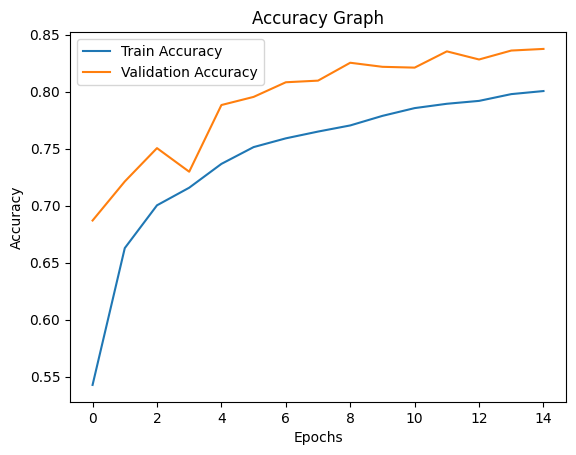

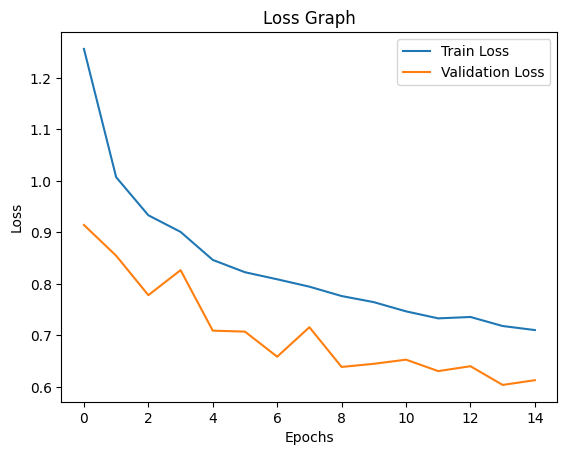

In [ ]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Accuracy Graph

- Training accuracy is steadily increasing (≈0.54 → 0.80) → model is learning from data

- Validation accuracy is also increasing (≈0.68 → 0.84) → model performs well on unseen data

- Validation accuracy is slightly higher than training accuracy → due to augmentation/dropout making training harder

- No major gap between train & validation → no overfitting observed

- Overall trend shows stable and consistent improvement

Loss Graph

- Training loss is continuously decreasing (≈1.25 → 0.71) → model errors are reducing

- Validation loss is also decreasing (≈0.91 → 0.60) → better generalization on unseen data

- Small fluctuations in validation loss → normal due to randomness in validation batches

- Validation loss is lower than training loss → indicates good regularization effect

- No divergence between train & validation loss → model is not overfitting

### Evaluate model (with Accuracy)

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8477 - loss: 0.5918
Test Accuracy: 0.8476666808128357


### Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step


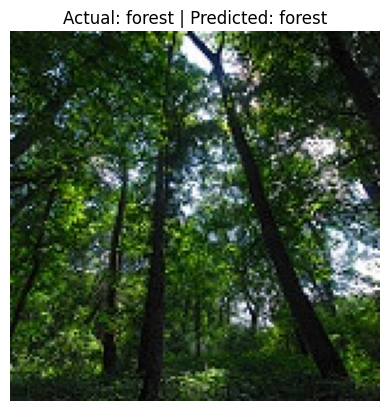

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


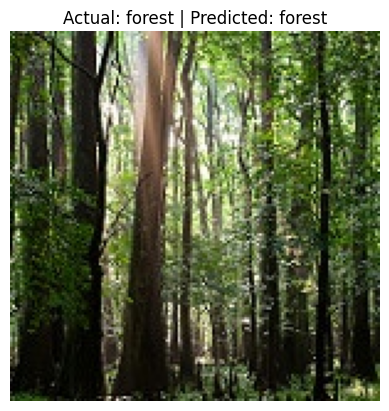

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


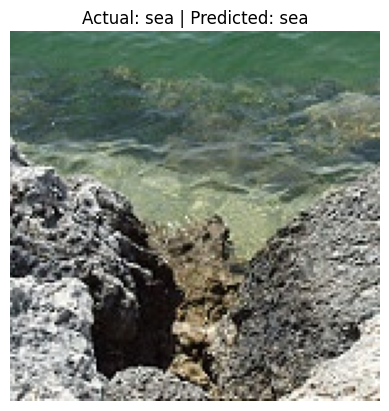

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


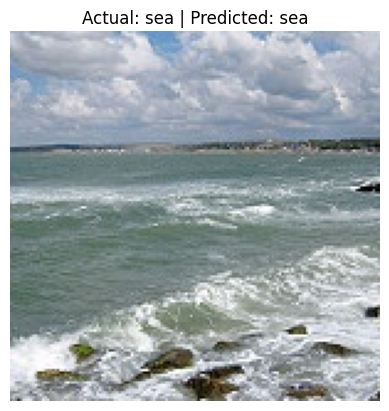

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


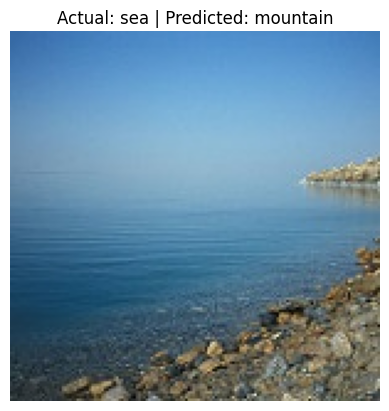

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


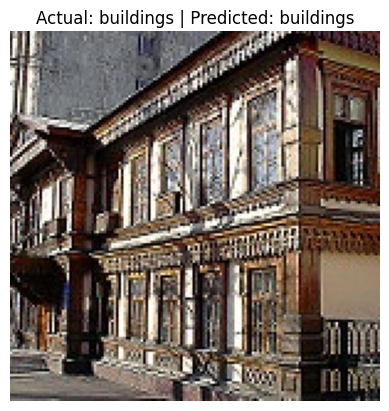

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


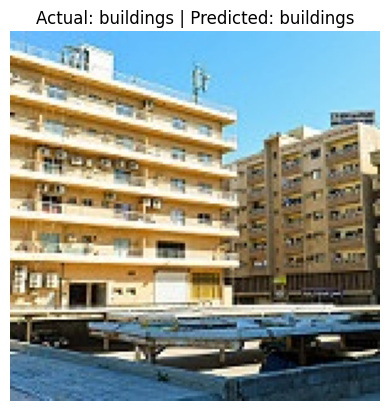

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


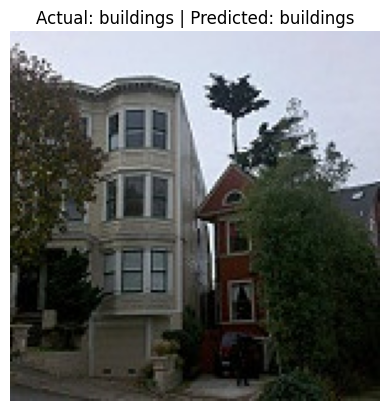

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


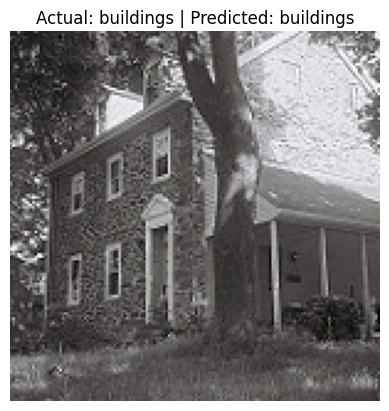

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


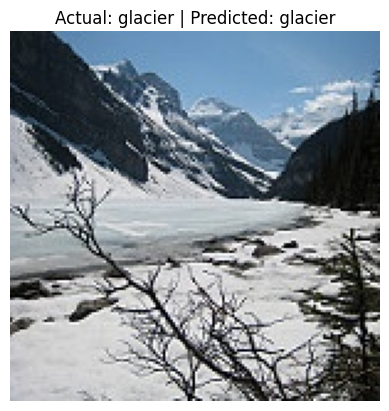

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


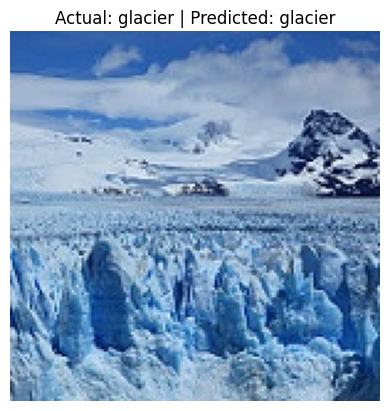

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


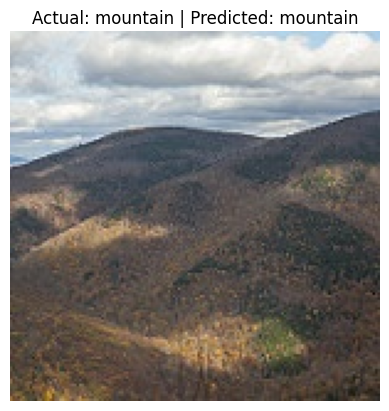

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


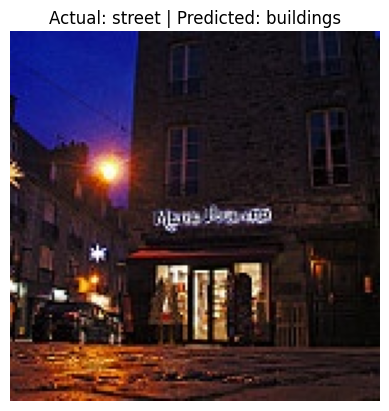

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


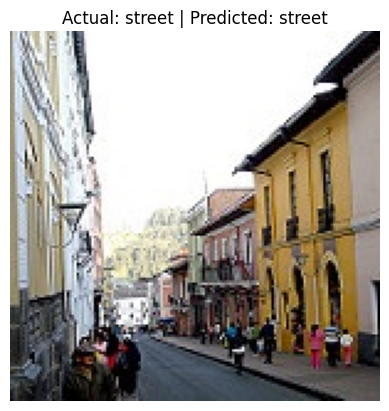

In [ ]:
import random
from tensorflow.keras.preprocessing import image

# Define how many images you want per class
samples_per_class = {
    "forest": 2,
    "sea": 3,
    "buildings": 4,
    "glacier": 2,
    "mountain": 1,
    "street": 2
}

img_size = (150, 150)

for class_name, num_samples in samples_per_class.items():

    class_path = os.path.join(test_dir, class_name)
    images = os.listdir(class_path)

    # Randomly pick images
    selected_images = random.sample(images, num_samples)

    for img_name in selected_images:
        img_path = os.path.join(class_path, img_name)

        # Load image
        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array)
        predicted_class = class_labels[np.argmax(prediction)]

        # Show image
        plt.imshow(img)
        plt.title(f"Actual: {class_name} | Predicted: {predicted_class}")
        plt.axis('off')
        plt.show()

- Model correctly predicted 12 out of 14 images. It means ~85.7% accuracy, showing good performance on unseen data

- A small number of errors (2 misclassifications) indicates minor confusion between similar classes

- Overall, the model demonstrates strong generalization with acceptable real-world performance